In [1]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

from icepop.convert_score import CrossSpeciesScoreConverter
from icepop.specificity_score import specificity_score

In [2]:
def linear_reg(X, y, eps=1e-12):
    # Replace NaNs
    X = np.where(np.isnan(X), 0.0, X)
    y = np.where(np.isnan(y), 0.0, y)

    # Ensure 2D
    if X.ndim == 1:
        X = X[None, :]   # (1, n_gene)

    k, n = X.shape

    # --- Mean-center if intercept implied
    y = y - np.mean(y)
    X = X - np.mean(X, axis=1, keepdims=True)

    # --- Regression core
    xy = X @ y                        # shape (k,)
    xx = np.sum(X**2, axis=1) + eps   # shape (k,)
    beta = xy / xx                    # shape (k,)

    # --- Residuals
    resid = y[None, :] - beta[:, None] * X
    rss = np.sum(resid**2, axis=1)
    s2 = rss / (n - 1)
    se = np.sqrt(s2 / (xx + eps))

    # --- t-statistics and one-sided p-values
    t = beta / (se + eps)
    pval = norm.sf(t)

    # --- DFBETAS (influence of each gene)
    h = (X**2) / (xx[:, None] + eps)
    dfb = ((X / (xx[:, None] + eps)) * resid) / (1 - h + eps)

    return beta, se, pval, dfb

In [3]:
adata = sc.read('../data/TM_FACS/TM_FACS_normed.h5ad')
spec = specificity_score(adata, n_jobs=20)
spec.get_celltype_spec_score()
spec_score = adata.uns['cell_type_spec_score']

# convert spec score across species
score_converter = CrossSpeciesScoreConverter(adata)
score_converter.generate_cross_sp_matrix()
spec_score = score_converter.convert_score_across_species(spec_score, normed=False)

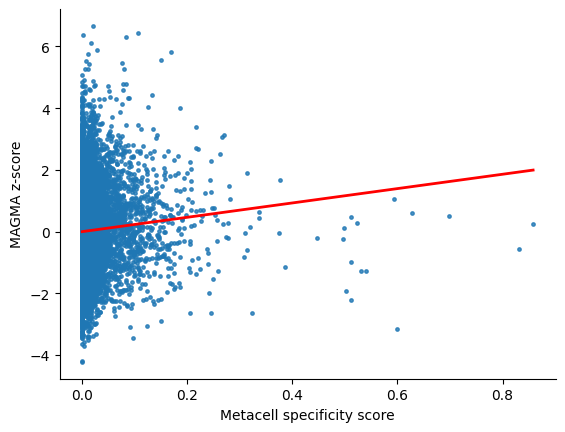

In [4]:
df = pd.read_csv('../data/TM_FACS/magmaz/PASS_MDD_Howard2019.genes.out', header=0, index_col=0, sep=r'\s+')
df.index = df.index.astype(str)
shared_genes = spec_score.columns.intersection(df.index)

tc = 'neuron'
X = spec_score.loc[tc, shared_genes].values
y = df.loc[shared_genes, 'ZSTAT'].values
y = y - y.mean()

beta, se, pval, dfb = linear_reg(X, y)
plt.scatter(X, y, s=6, alpha=0.8)
x_fit = np.linspace(X.min(), X.max(), 200)
y_fit = beta[0] * x_fit
plt.plot(x_fit, y_fit, linewidth=2, c='red')

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("Metacell specificity score")
plt.ylabel("MAGMA z-score")
plt.savefig('../paper/schematics/workflow_A.pdf')

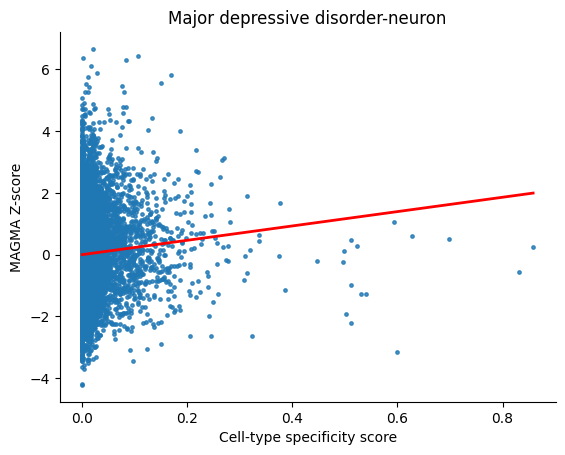

In [5]:
df = pd.read_csv('../data/TM_FACS/magmaz/PASS_MDD_Howard2019.genes.out', header=0, index_col=0, sep=r'\s+')
df.index = df.index.astype(str)
shared_genes = spec_score.columns.intersection(df.index)

tc = 'neuron'
X = spec_score.loc[tc, shared_genes].values
y = df.loc[shared_genes, 'ZSTAT'].values
y = y - y.mean()

beta, se, pval, dfb = linear_reg(X, y)
plt.scatter(X, y, s=6, alpha=0.8)
x_fit = np.linspace(X.min(), X.max(), 200)
y_fit = beta[0] * x_fit
plt.plot(x_fit, y_fit, linewidth=2, c='red')

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("Cell-type specificity score")
plt.ylabel("MAGMA Z-score")
plt.title("Major depressive disorder-neuron")
plt.savefig('../paper/supp/seismic_positive.pdf')

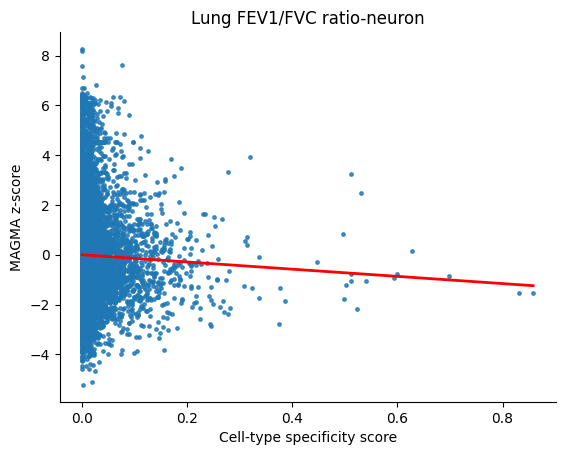

In [6]:
df = pd.read_csv('../data/TM_FACS/magmaz/UKB_460K.lung_FEV1FVCzSMOKE.genes.out', header=0, index_col=0, sep=r'\s+')

df.index = df.index.astype(str)
shared_genes = spec_score.columns.intersection(df.index)

tc = 'neuron'
X = spec_score.loc[tc, shared_genes].values
y = df.loc[shared_genes, 'ZSTAT'].values
y = y - y.mean()

beta, se, pval, dfb = linear_reg(X, y)
plt.scatter(X, y, s=6, alpha=0.8)
x_fit = np.linspace(X.min(), X.max(), 200)
y_fit = beta[0] * x_fit
plt.plot(x_fit, y_fit, linewidth=2, c='red')

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("Cell-type specificity score")
plt.ylabel("MAGMA z-score")
plt.title("Lung FEV1/FVC ratio-neuron")
plt.savefig('../paper/supp/seismic_negative.pdf')

/tmp/ipykernel_657771/3597541997.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


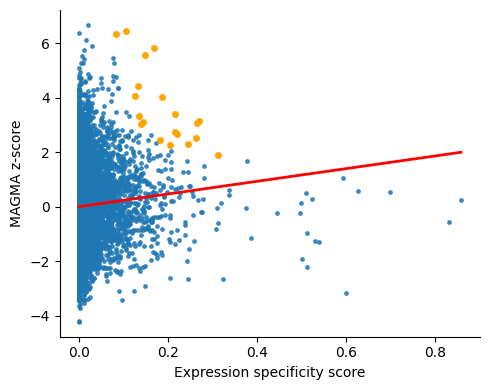

In [7]:
df = pd.read_csv('../data/TM_FACS/magmaz/PASS_MDD_Howard2019.genes.out', header=0, index_col=0, sep=r'\s+')
df.index = df.index.astype(str)
shared_genes = spec_score.columns.intersection(df.index)

tc = 'neuron'
X = spec_score.loc[tc, shared_genes].values
y = df.loc[shared_genes, 'ZSTAT'].values
y = y - y.mean()

beta, se, pval, dfb = linear_reg(X, y)

# -----------------------
# Top 20 influential points
# -----------------------
top_k = 20
top_idx = np.argsort(dfb.ravel())[-top_k:]   # indices of top |DFBETA|

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(5, 4))

# all points
plt.scatter(X, y, s=6, alpha=0.8)

# highlight top DFBETA points
plt.scatter(
    X[top_idx],
    y[top_idx],
    s=20,
    color="orange",
    linewidth=0.5,
)

# regression line
x_fit = np.linspace(X.min(), X.max(), 200)
y_fit = beta[0] * x_fit
plt.plot(x_fit, y_fit, linewidth=2, color="red")

plt.xlabel("Expression specificity score")
plt.ylabel("MAGMA z-score")
plt.title("")
plt.legend(frameon=False)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig('../paper/schematics/influ.pdf')

## mixture

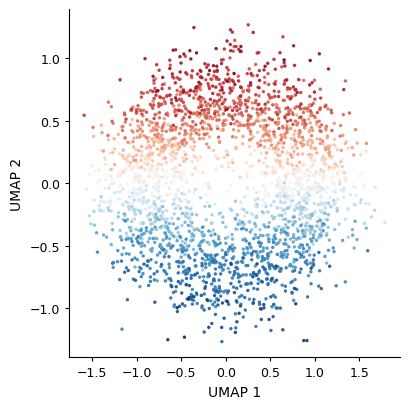

In [8]:
np.random.seed(0)

# -----------------------------
# 1. UMAP-like manifold
# -----------------------------
n = 2500

theta = np.random.uniform(0, 2*np.pi, n)
r = np.random.normal(1.0, 0.25, n)

x = r * np.cos(theta) + np.random.normal(0, 0.15, n)
y = 0.7 * r * np.sin(theta) + np.random.normal(0, 0.15, n)

# -----------------------------
# 2. Association (top–bottom)
# -----------------------------
assoc = np.tanh(y * 1.5) + np.random.normal(0, 0.1, n)
assoc = np.clip(assoc, -1.2, 1.2)

# -----------------------------
# 3. Plot (schematic)
# -----------------------------
fig, ax = plt.subplots(figsize=(4.2, 4.2))

ax.scatter(
    x, y,
    c=assoc,
    cmap="RdBu_r",
    s=6,
    linewidths=0,
    alpha=0.9
)

# -----------------------------
# Style: minimal schematic
# -----------------------------
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)

ax.tick_params(axis="both", which="both", length=3, labelsize=9)

plt.tight_layout()
plt.savefig('../paper/schematics/hetero.pdf')

In [9]:
def plot_umap(adata, col, cmap='Reds', palette=None, vmin=None, vmax=None, title=None, outfile=None):
    # Determine if we use custom scaling
    use_limits = isinstance(vmin, (float, int)) and isinstance(vmax, (float, int))
    
    # Generate the plot
    if palette:
        ax = sc.pl.umap(
            adata,
            color=col,
            show=False,
            palette=palette,
            vmin=vmin if use_limits else None,
            vmax=vmax if use_limits else None,
            colorbar_loc=None
        )
    else:
        ax = sc.pl.umap(
            adata,
            color=col,
            show=False,
            cmap=cmap,
            vmin=vmin if use_limits else None,
            vmax=vmax if use_limits else None,
            colorbar_loc=None
        )

    # 1. Remove the top and right "border" (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 2. Ensure bottom and left spines are visible
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

    # 3. Add ticks and labels back
    ax.set_xticks([]) # Or use ax.xaxis.set_visible(True) for default behavior
    ax.set_yticks([])
    
    # If you want numeric tick labels, use these instead:
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

    # 4. Remove title
    if not title:
        ax.set_title("")
    else:
        ax.set_title(title)

    if outfile:
        plt.tight_layout()
        plt.savefig(outfile)
    else:
        plt.show()

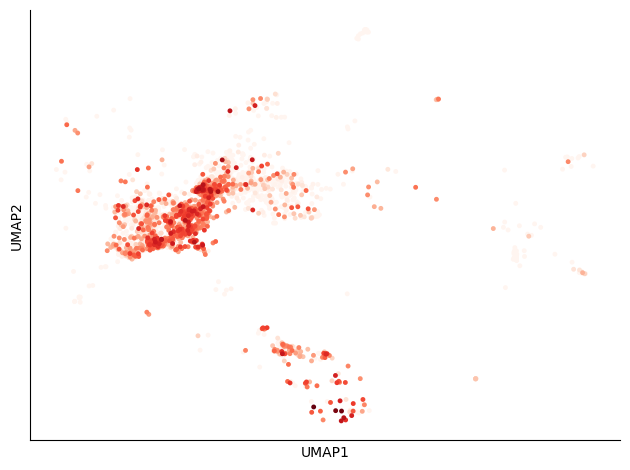

In [10]:
plot_umap(adata[adata.obs['cell_type'] == 'macrophage'], '22793', cmap='Reds', outfile='../paper/schematics/workflow_B.pdf')